In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv("../data/online_retail_09_10.csv", parse_dates=["InvoiceDate"])
df2 = pd.read_csv("../data/online_retail_10_11.csv", parse_dates=["InvoiceDate"])

# The two files overlap: everything from 2010-12-01 to 2010-12-09 is in BOTH.
# Concatenating as-is double counts those invoices (Monetary / order values get doubled).
overlap_start = df2["InvoiceDate"].min().normalize()
shared_invoices = set(df1["InvoiceNo"].astype(str)) & set(df2["InvoiceNo"].astype(str))
print(f"Overlap window starts: {overlap_start.date()}")
print(f"Rows in file 1 inside overlap window: {(df1['InvoiceDate'] >= overlap_start).sum():,}")
print(f"Invoices present in both files:       {len(shared_invoices):,}")

# Keep file 1 only up to the day before file 2 starts
df1 = df1[df1["InvoiceDate"] < overlap_start].copy()

assert not (set(df1["InvoiceNo"].astype(str)) & set(df2["InvoiceNo"].astype(str))), "files still overlap"
print("Overlap removed - no invoice appears in both files")

Overlap window starts: 2010-12-01
Rows in file 1 inside overlap window: 22,523
Invoices present in both files:       1,088


Overlap removed - no invoice appears in both files


In [3]:
df1.shape

(502938, 8)

In [4]:
df2.shape

(541910, 8)

In [5]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df2.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df = pd.concat([df1, df2], ignore_index=True)
df.shape

(1044848, 8)

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [10]:
#Data Cleaning

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     235287
Country             0
Sales               0
dtype: int64

In [12]:
# Removing rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

df['CustomerID'] = df['CustomerID'].astype(int)

print(df.shape)

(809561, 9)


In [13]:
# Removing cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(df.shape)

(791115, 9)


In [14]:
# Removing negative or zero values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print(df.shape)

(791045, 9)


In [15]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 791045 entries, 0 to 1044847
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    791045 non-null  str           
 1   StockCode    791045 non-null  str           
 2   Description  791045 non-null  str           
 3   Quantity     791045 non-null  int64         
 4   InvoiceDate  791045 non-null  datetime64[us]
 5   UnitPrice    791045 non-null  float64       
 6   CustomerID   791045 non-null  int64         
 7   Country      791045 non-null  str           
 8   Sales        791045 non-null  float64       
 9   Year         791045 non-null  int32         
 10  Month        791045 non-null  int32         
 11  Day          791045 non-null  int32         
 12  Hour         791045 non-null  int32         
dtypes: datetime64[us](1), float64(2), int32(4), int64(2), str(4)
memory usage: 72.4 MB


In [17]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales,Year,Month,Day,Hour
count,791045.000000,791045,791045.000000,791045.000000,791045.000000,791045.000000,791045.000000,791045.000000,791045.000000
mean,13.334006,2011-01-02 22:38:49.200766,3.208401,15327.095703,22.036106,2010.431042,7.424906,15.389827,12.799826
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,6.000000
25%,2.000000,2010-07-02 14:15:00,1.250000,13979.000000,4.950000,2010.000000,5.000000,8.000000,11.000000
50%,5.000000,2010-12-02 11:22:00,1.950000,15259.000000,11.900000,2010.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-08-01 14:57:00,3.750000,16797.000000,19.500000,2011.000000,11.000000,23.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,144.797886,NaN,29.458890,1695.028222,225.762659,0.568331,3.423487,8.656544,2.291280


In [18]:
monthly_sales = df.groupby(["Year","Month"])["Sales"].sum().reset_index()

monthly_sales.head()

,Year,Month,Sales
0,2009,12,686654.160
1,2010,1,557319.062
2,2010,2,506371.066
3,2010,3,699608.991
4,2010,4,594609.192


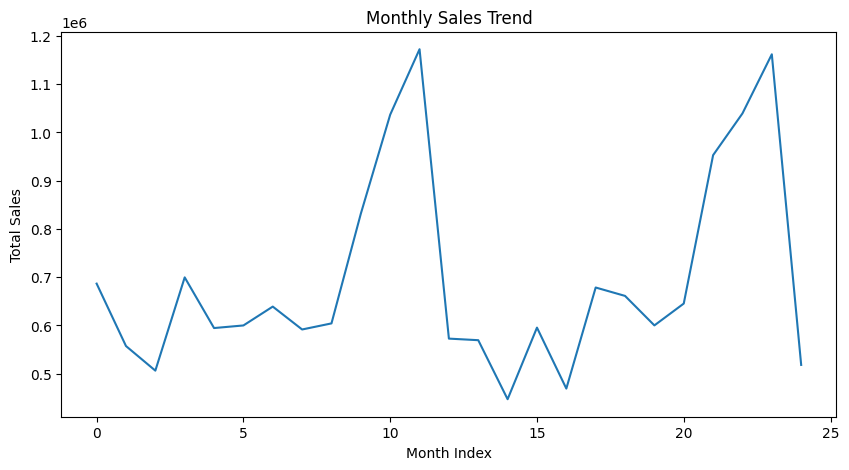

In [19]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales["Sales"])

plt.title("Monthly Sales Trend")
plt.xlabel("Month Index")
plt.ylabel("Total Sales")

plt.show()

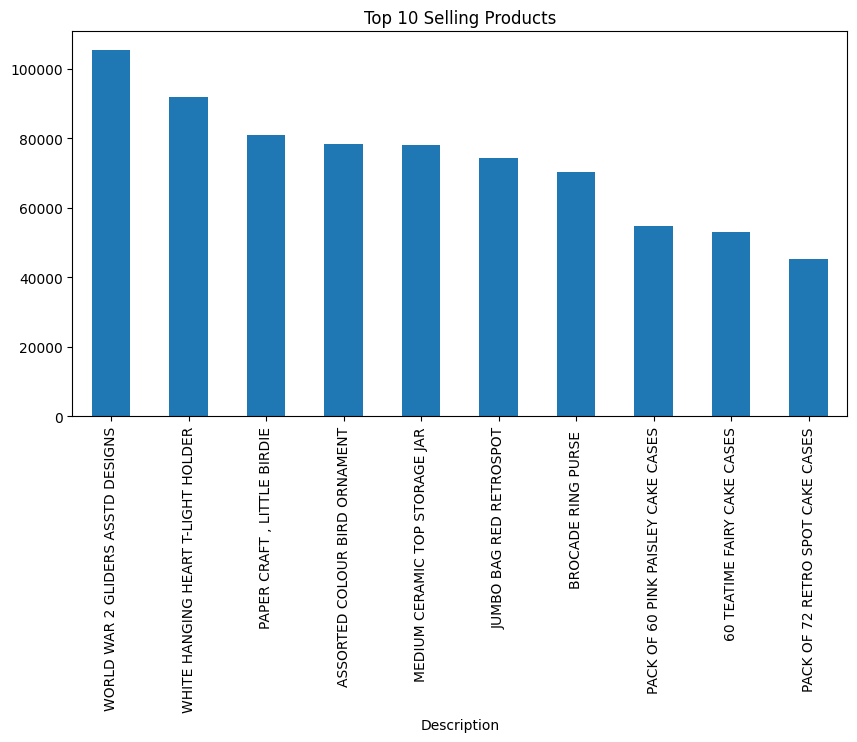

In [20]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Selling Products")

plt.show()

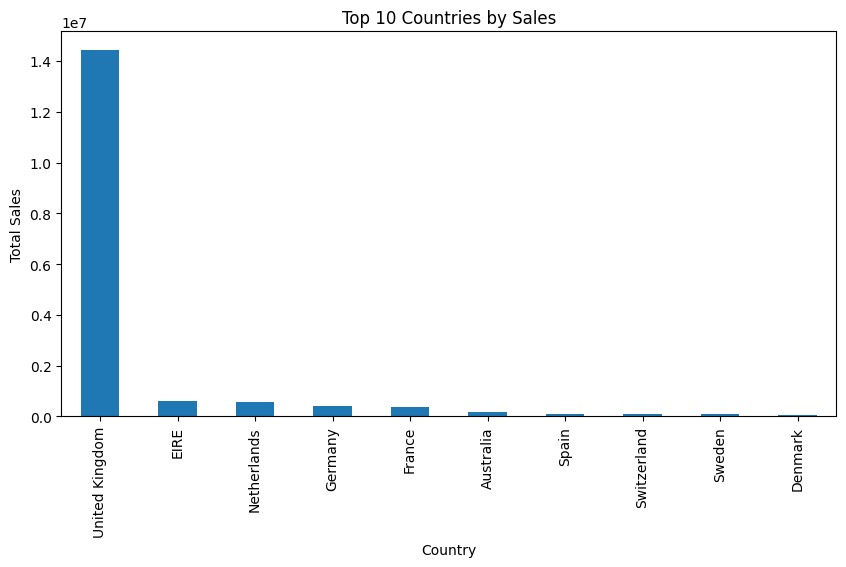

In [21]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.show()

In [22]:
product_demand = df.groupby("StockCode")["Quantity"].sum().reset_index()

product_demand = product_demand.sort_values(by="Quantity", ascending=False)

product_demand.head(10)

,StockCode,Quantity
3410,84077,105425
4058,85099B,93610
4080,85123A,91934
601,21212,89938
2726,23843,80995
3819,84879,78445
2324,23166,77916
1405,22197,76982
108,17003,70118
1219,21977,54761


In [23]:
# Same reference date as the churn notebook (last transaction), so Recency matches in both
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,12,77556.46
12347,1,8,4921.53
12348,74,5,2019.40
12349,18,4,4428.69
12350,309,1,334.40


In [24]:
rfm.shape

(5878, 3)

In [25]:
from sklearn.preprocessing import StandardScaler

# Frequency and Monetary are extremely right-skewed. On raw values a few wholesale-sized
# customers dominate KMeans distances and end up in their own tiny clusters.
# log1p first, then standardise.
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])

print("Skew before log:", rfm[["Recency", "Frequency", "Monetary"]].skew().round(2).to_dict())
print("Skew after log: ", rfm_log.skew().round(2).to_dict())

scaler = StandardScaler()
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log),
    columns=rfm_log.columns,
    index=rfm.index
)

rfm_scaled.head()

Skew before log: {'Recency': 0.89, 'Frequency': 12.64, 'Monetary': 25.05}
Skew after log:  {'Recency': -0.62, 'Frequency': 1.0, 'Monetary': 0.27}


,Recency,Frequency,Monetary
CustomerID,,,
12346,0.843417,1.254496,3.204067
12347,-2.269860,0.800166,1.212488
12348,-0.054680,0.299207,0.569242
12349,-0.893881,0.073946,1.136288
12350,0.812658,-1.058146,-0.727848


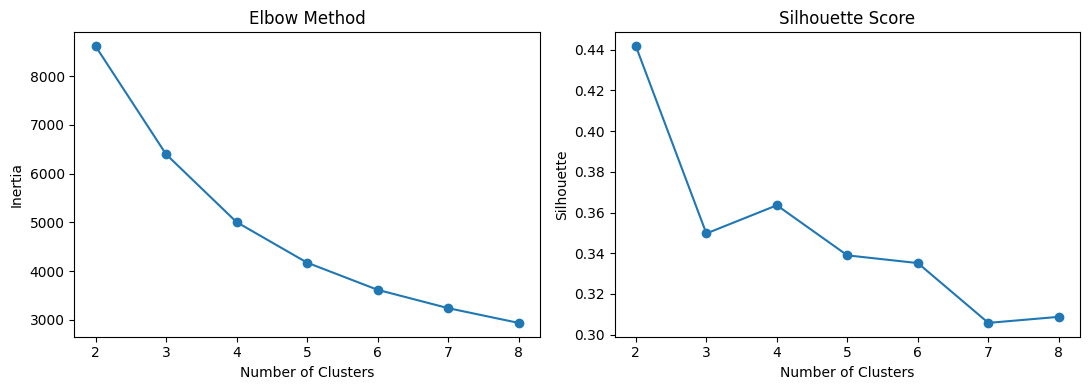

k=2: silhouette=0.442
k=3: silhouette=0.350
k=4: silhouette=0.364
k=5: silhouette=0.339
k=6: silhouette=0.335
k=7: silhouette=0.306
k=8: silhouette=0.309


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette.append(
        silhouette_score(rfm_scaled, labels_k, sample_size=5000, random_state=42)
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

for k, sc in zip(k_range, silhouette):
    print(f"k={k}: silhouette={sc:.3f}")

In [27]:
# k=4 gives four actionable segments. Silhouette is highest at k=2 but that only separates
# active vs lapsed customers, which is too coarse for targeted interventions.
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Cluster sizes:")
print(rfm["Cluster"].value_counts().sort_index())

rfm.head()

Cluster sizes:
Cluster
0    1213
1    1486
2    2072
3    1107
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,325,12,77556.46,3
12347,1,8,4921.53,3
12348,74,5,2019.40,1
12349,18,4,4428.69,0
12350,309,1,334.40,2


In [28]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(1)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,1213,26.6,3.0,847.4
1,1486,208.4,5.4,2123.3
2,2072,390.3,1.4,342.1
3,1107,24.3,20.1,11327.6


In [29]:

# Label clusters from their behaviour (not from cluster ids, which are arbitrary):
#   recently active clusters : highest spend -> Champions, the rest -> Promising
#   lapsed clusters          : less stale    -> At Risk,   most stale -> Lost Customers
by_recency = cluster_profile.sort_values("Avg_Recency")
half = len(by_recency) // 2
recent_ids = by_recency.index[:half].tolist()
lapsed_ids = by_recency.index[half:].tolist()

cluster_to_label = {}

recent_sorted = cluster_profile.loc[recent_ids].sort_values("Avg_Monetary", ascending=False).index.tolist()
cluster_to_label[recent_sorted[0]] = "Champions"
for c in recent_sorted[1:]:
    cluster_to_label[c] = "Promising"

lapsed_sorted = cluster_profile.loc[lapsed_ids].sort_values("Avg_Recency").index.tolist()
cluster_to_label[lapsed_sorted[0]] = "At Risk"
for c in lapsed_sorted[1:]:
    cluster_to_label[c] = "Lost Customers"

rfm["Segment_Label"] = rfm["Cluster"].map(cluster_to_label)
cluster_profile["Segment_Label"] = cluster_profile.index.map(cluster_to_label)

print("Cluster -> Segment:", cluster_to_label)
cluster_profile.sort_values("Avg_Recency")


Cluster -> Segment: {3: 'Champions', 0: 'Promising', 1: 'At Risk', 2: 'Lost Customers'}


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Segment_Label
Cluster,,,,,
3,1107,24.3,20.1,11327.6,Champions
0,1213,26.6,3.0,847.4,Promising
1,1486,208.4,5.4,2123.3,At Risk
2,2072,390.3,1.4,342.1,Lost Customers


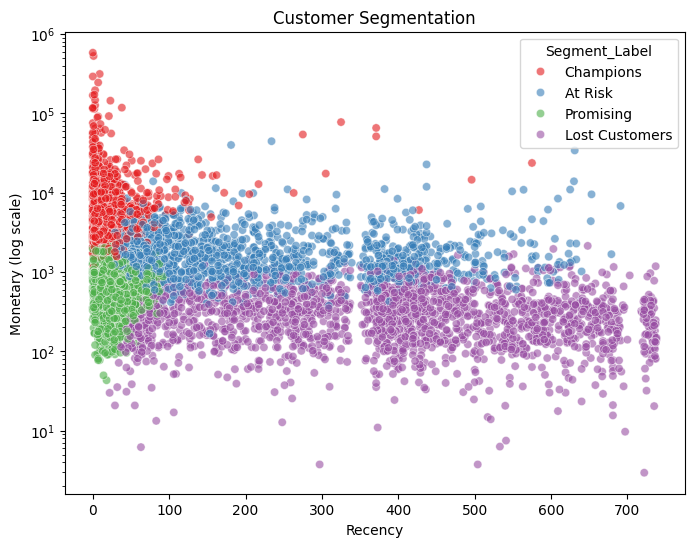

In [30]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment_Label",
    palette="Set1",
    alpha=0.6
)

plt.yscale("log")
plt.title("Customer Segmentation")
plt.ylabel("Monetary (log scale)")

plt.show()

In [31]:
# Save cleaned transaction-level data (overlap already removed)
df.to_csv("../data/processed_retail_data.csv", index=False)
print(f"Saved processed_retail_data.csv - {df.shape[0]:,} rows")

Saved processed_retail_data.csv - 791,045 rows


In [32]:
# Save RFM + segment labels (used by the churn notebook).
# Built straight from the fitted `rfm` table, so CustomerID and Cluster can't get misaligned.
rfm_export = rfm.reset_index()[
    ["CustomerID", "Recency", "Frequency", "Monetary", "Cluster", "Segment_Label"]
]

rfm_export.to_csv("../data/rfm_segments.csv", index=False)
print(f"Saved rfm_segments.csv - {rfm_export.shape[0]:,} customers")
rfm_export.head()

Saved rfm_segments.csv - 5,878 customers


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment_Label
0,12346,325,12,77556.46,3,Champions
1,12347,1,8,4921.53,3,Champions
2,12348,74,5,2019.40,1,At Risk
3,12349,18,4,4428.69,0,Promising
4,12350,309,1,334.40,2,Lost Customers
